In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [3]:
#Data preprocessing
dataset = pd.read_csv('train.csv')

X_train = dataset.drop(columns=['Target'])
y_train = dataset['Target']

ones = np.ones((X_train.shape[0], 1))
X_train = np.column_stack([ones, X_train.values])

x0 = np.array([-1.47, 0, 0, 0, 0])

In [4]:
def f_sum(x, U, v):
    dots = U @ x
    return np.sum((1 - v) * dots + np.logaddexp(0, -dots))

def grad_f_eval(x, U, v):
    g = 1/(1+np.exp(-U@x))
    return U.T @ (g-v)

In [ ]:
# Task c.)
def gradient_method_const(f, x0, U, v, c=3e-5, epsilon=1e-3, max_iters=5_000_000):
    x = x0.astype(float).copy()
    k = 0
    x_iter = [x.copy()]
    f_val = [f(x, U, v)]
    while k < max_iters:
        grad = U.T @ (1/(1+np.exp(-U@x)) - v)
        if np.linalg.norm(grad) <= epsilon:
            break
        x -= c * grad
        k += 1
        x_iter.append(x.copy())
        f_val.append(f(x, U, v))

    f_val_check = all(f_val[i] >= f_val[i+1] for i in range(len(f_val)-1))
    print(f"Hodnota ucelovej funkcie nerastie: {f_val_check}")
    print(f"Pocet iteracii: {k}")

    return x, x_iter

import time

print(f"\n--- c = 3e-7 ---")
start = time.time()
vysl_1_1 = gradient_method_const(f_sum, x0, X_train, y_train.values,
                                     c=3e-7)

elapsed = time.time() - start
print(f"Výsledok: {vysl_1_1[0]}")
print(f"Čas: {elapsed:.2f}s")

print(f"\n--- c = 3e-5 ---")
start = time.time()
vysl_1_2 = gradient_method_const(f_sum, x0, X_train, y_train.values,
                                     c=3e-5)

elapsed = time.time() - start
print(f"Výsledok: {vysl_1_2[0]}")
print(f"Čas: {elapsed:.2f}s")

print(f"\n--- c = 3e-3 ---")
start = time.time()
vysl_1_3 = gradient_method_const(f_sum, x0, X_train, y_train.values,
                                     c=3e-3)

elapsed = time.time() - start
print(f"Výsledok: {vysl_1_3[0]}")
print(f"Čas: {elapsed:.2f}s")


--- c = 3e-7 ---
Hodnota ucelovej funkcie nerastie: True
Pocet iteracii: 200000
Výsledok: [-0.31826316  1.21423471  0.72325621  0.67048146  0.01015566]
Čas: 13.85s

--- c = 3e-5 ---
Hodnota ucelovej funkcie nerastie: True
Pocet iteracii: 200000
Výsledok: [-1.27195395e+00  3.03778572e+00  7.94458913e+00  1.15373874e+01
  6.04713846e-03]
Čas: 13.42s

--- c = 3e-3 ---
Hodnota ucelovej funkcie nerastie: False
Pocet iteracii: 200000
Výsledok: [-8.35936966e+00  8.27668716e+00  2.26341492e+01  4.81816159e+01
  1.14771265e-02]
Čas: 14.40s


In [ ]:
# Task d.)

def gradient_method_backtracking(f, x0, U, v, alpha=0.499, delta=0.8, epsilon=1e-3, max_iters=5_000_000):
    x = x0.astype(float).copy()
    k = 0

    x_iter = [x.copy()]
    l_min = np.inf
    l_max = np.nan

    while k < max_iters:
        grad = grad_f_eval(x, U, v)

        if np.linalg.norm(grad) <= epsilon:
            break

        d = -grad
        lambda_k = 0.2

        fx = f(x, U, v)
        dot = np.dot(grad, d) * alpha
        while f(x + lambda_k * d, U, v) > fx + dot * lambda_k:
            lambda_k *= delta

        if(k == 0):
            l_max = lambda_k

        x += lambda_k * d
        k += 1
        if (k % 10_000 == 0):
            print(k)

        l_min = min(l_min, lambda_k)

    print(f"Pocet iteracii: {k}")
    print(f"lambda_min = {l_min}")
    print(f"lambda_max = {l_max}")

    return (x, x_iter, l_min, l_max)

start = time.time()
vysl_2 = gradient_method_backtracking(f_sum, x0, X_train, y_train.values)
elapsed = time.time() - start
print(f"Čas: {elapsed:.2f}s")
print(f"f_1 ma minimum priblizne v bode {vysl_2[0]} \n")
l_max, l_min = vysl_2[2], vysl_2[3]

10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
Pocet iteracii: 200000
lambda_min = 5.575186299632669e-06
lambda_max = 6.9689828745408365e-06
Čas: 314.71s
f_1 ma minimum priblizne v bode [-1.46845795e+00  3.07099273e+00  1.02496768e+01  1.74387704e+01
  4.89800396e-03] 



In [ ]:
# Tasks e.)
def golden_section(f, a, b, tol=1e-6):

    phi = (1 + np.sqrt(5))/2
    rho = phi - 1

    c1 = rho*a + (1 - rho)*b
    f1 = f(c1)
    c2 = (1 - rho)*a + rho*b
    f2 = f(c2)

    while abs(b - a) > tol:

        if f1 < f2:
            b = c2
            c2 = c1
            f2 = f1
            c1 = rho*a + (1 - rho)*b
            f1 = f(c1)
        else:
            a = c1
            c1 = c2
            f1 = f2
            c2 = (1 - rho)*a + rho*b
            f2 = f(c2)

    return (a+b)/2

def cauchy_method(f, x0, U, v, a, b, epsilon=1e-3, max_iters=5_000_000):
    x = x0.astype(float).copy()
    k = 0

    x_iter = [x.copy()]

    while k < max_iters:

        grad = grad_f_eval(x, U, v)
        d = -grad

        if np.linalg.norm(grad) <= epsilon:
            break

        def f_new(z):
            return f(x + z * d, U, v)

        lambda_k = golden_section(f_new, a, b)

        x = x + lambda_k * d
        x_iter.append(x.copy())

        k += 1

    print(f"Pocet iteracii: {k}")
    return x, x_iter
start = time.time()
vysl_3_1 = gradient_method_backtracking(f_sum, x0, X_train, y_train.values, 0.1*l_min, 10*l_max)
elapsed = time.time() - start
print(f"Čas: {elapsed:.2f}s")
print(f"f_1 ma minimum priblizne v bode {vysl_3_1[0]} \n")

start = time.time()
vysl_3_2 = gradient_method_backtracking(f_sum, x0, X_train, y_train.values, l_min, l_max)
elapsed = time.time() - start
print(f"Čas: {elapsed:.2f}s")
print(f"f_1 ma minimum priblizne v bode {vysl_3_2[0]} \n")

10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
Pocet iteracii: 200000
lambda_min = 1.1150372599265338e-05
lambda_max = 1.1150372599265338e-05
Čas: 31.14s
f_1 ma minimum priblizne v bode [-1.38019572e+00  3.04964263e+00  9.30670767e+00  1.42436320e+01
  5.55353946e-03] 

10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
Pocet iteracii: 200000
lambda_min = 1.1150372599265338e-06
lambda_max = 1.1150372599265338e-06
Čas: 30.70s
f_1 ma minimum priblizne v bode [-1.03747157  3.21069534  4.2097568   5.11648482  0.00791834] 



In [9]:


# Minimum
res = minimize(
    fun=lambda x: f_sum(x, X_train, y_train),
    x0=x0,
    method="BFGS"
)

# Results for c.) - e.)

# #x_opt_ref = res.x
# x_opt_ref = np.array([-1.47377220e+00,  3.07173693e+00,  1.01906655e+01,  1.77027043e+01, 4.84402783e-03])
# print("Referenčné riešenie:", x_opt_ref)

# # Constant step
# # Number of iterations: 2736859
# # Time: 1m 6.4s
# x_1 = np.array([-1.47360963e+00,  3.07175527e+00,  1.01989855e+01,  1.76905539e+01, 4.84667713e-03])
# print(f"c\t\t   : {x_1}, chyba: {np.linalg.norm(x_1 - x_opt_ref)}\n")
# # print(f"c\t\t   : {vysl_1[0]}, chyba: {np.linalg.norm(vysl_1[0] - x_opt_ref)}\n")

# # Approximately optimal step
# # Number of iterations: 633840
# # Time: 3m 28.0s
# x_2 = np.array([-1.47361102e+00,  3.07175538e+00,  1.01989558e+01,  1.76906325e+01, 4.84665901e-03])
# print(f"d\t\t   : {x_2}, chyba: {np.linalg.norm(x_2 - x_opt_ref)} \n")
# # print(f"d\t\t   : {vysl_2[0]}, chyba: {np.linalg.norm(vysl_2[0] - x_opt_ref)} \n")

# # Golden section on [0.1*l_min, 10*l_max]
# # Number of iterations: 2472704
# # Time: 4m 6.8s
# x_3 = np.array([-1.47363523e+00,  3.07175410e+00, 1.01979473e+01,  1.76922987e+01, 4.84631001e-03])
# print(f"e\t\t   : {x_3}, chyba: {np.linalg.norm(x_3 - x_opt_ref)} \n")
# # print(f"e\t\t   : {vysl_3_1[0]}, chyba: {np.linalg.norm(vysl_3_1[0] - x_opt_ref)} \n")

# # Golden section on [l_min, l_max]
# # Number of iterations: 3000000 (max_iter)
# # Time: 1m 42.0s
# x_4 = np.array([-1.43329736e+00,  3.06269986e+00,  9.99405599e+00,  1.61372798e+01, 5.15234320e-03])
# print(f"e\t\t   : {x_4}, chyba: {np.linalg.norm(x_4 - x_opt_ref)} \n")
# # print(f"e\t\t   : {vysl_3_2[0]}, chyba: {np.linalg.norm(vysl_3_2[0] - x_opt_ref)} \n")


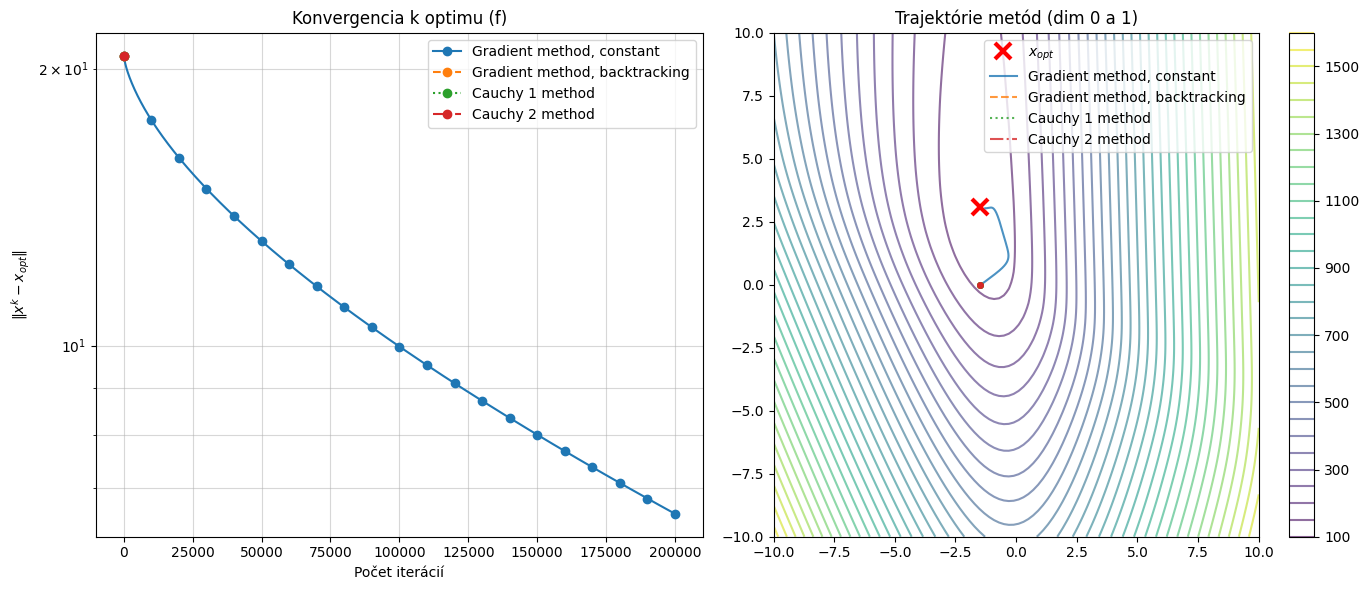

In [23]:
def distance(x_k, x_opt):
    x_k = np.array(x_k)
    return np.linalg.norm(x_k - x_opt, axis=1)

def plot_distance(vysl_1, vysl_2, vysl_3, vysl_4, vysl_opt, f, 
                  X_train, y_train,
                  x_range=(-10, 10), y_range=(-10, 10), title="f"):
    
    x_opt = vysl_opt.x
    vysledky = [np.array(v) for v in [vysl_1, vysl_2, vysl_3, vysl_4]]
    labels = ['Gradient method, constant', 'Gradient method, backtracking', 
              'Cauchy 1 method', 'Cauchy 2 method']
    styles = ['-', '--', ':', '-.']
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    for i, v in enumerate(vysledky):
        dist = np.linalg.norm(v - x_opt, axis=1)
        ax1.semilogy(dist, label=labels[i], linestyle=styles[i], color=colors[i],
                     marker='o', markevery=max(1, len(v)//20)) 

    ax1.set_xlabel("Počet iterácií")
    ax1.set_ylabel(r"$\Vert x^{k} - x_{opt} \Vert$")
    ax1.set_title(f"Konvergencia k optimu ({title})")
    ax1.grid(True, which="both", ls="-", alpha=0.5)
    ax1.legend()

    x1_vals = np.linspace(*x_range, 100)
    x2_vals = np.linspace(*y_range, 100)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    
    Z = np.zeros_like(X1)
    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            x_param = x_opt.copy()
            x_param[0] = X1[i, j]
            x_param[1] = X2[i, j]
            Z[i, j] = f(x_param, X_train, y_train)

    contour = ax2.contour(X1, X2, Z, levels=30, cmap='viridis', alpha=0.6)
    fig.colorbar(contour, ax=ax2)
    
    ax2.plot(x_opt[0], x_opt[1], "rx", ms=12, mew=3, label="$x_{opt}$")

    for i, v in enumerate(vysledky):
        ax2.plot(v[:, 0], v[:, 1], label=labels[i], color=colors[i], 
                 linestyle=styles[i], alpha=0.8)
        ax2.plot(v[0, 0], v[0, 1], 'o', color=colors[i], ms=4)

    ax2.set_xlim(x_range)
    ax2.set_ylim(y_range)
    ax2.set_title(f"Trajektórie metód (dim 0 a 1)")
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_distance(vysl_1_2[1], vysl_2[1], vysl_3_1[1], vysl_3_2[1], res, f_sum, X_train, y_train)
